In [2]:
import numpy as np
import matplotlib.pyplot as plt
import athena_mc as athenamc
from scipy.optimize import curve_fit
from scipy.integrate import quad

In [3]:
folder = "xrb_d01_s3_1e9"

Read in `.spec` file and convert it to a `.txt` file.

In [4]:
spec = athenamc.read_spectrum(f"../{folder}/xrb.out1.spec")

imu = 0
iphi = 0

xfaces = spec['xfaces']
x = 0.5*(xfaces[1:]+xfaces[:-1])
y = spec["intensity"][0,iphi,imu,:]
yerr = spec["errors"][0,iphi,imu,:]

print(x.shape, y.shape, yerr.shape)

np.savetxt(
    "output.txt",
    np.column_stack([x, y, yerr]),
    header="x y yerr"
)

(48,) (48,) (48,)


Define `pow()`, `bb()`, and `diskbb()` functions.

In [5]:
def power_law(E, A, alpha):
    return A * E**(-alpha)

def pow(x, y, yerr):

    popt, pcov = curve_fit(power_law, x, y, sigma=yerr, absolute_sigma=True, p0=[1e25, 2])

    A_fit, alpha_fit = popt
    A_err, alpha_err = np.sqrt(np.diag(pcov))

    print("power law fit parameters:")
    print(f"A = {A_fit:.3e} ± {A_err:.3e}")
    print(f"alpha = {alpha_fit:.3f} ± {alpha_err:.3f}")
    print()

    return A_fit, A_err, alpha_fit, alpha_err

In [6]:
def blackbody(E, A, T):
    return A * (E**3) / (np.exp(E / T) - 1)

def bb(x, y, yerr):

    popt, pcov = curve_fit(blackbody, x, y, sigma=yerr, absolute_sigma=True, p0=[1e10, 100])
    
    A_fit, T_fit = popt
    A_err, T_err = np.sqrt(np.diag(pcov))

    print("bb fit parameters:")
    print(f"A = {A_fit:.3e} ± {A_err:.3e}")
    print(f"T = {T_fit:.3f} ± {T_err:.3f}")
    print()

    return A_fit, A_err, T_fit, T_err

In [7]:
def diskbb_model(E, A, Tin, Tout):

    def integrand(T, E):
        return (T / Tin)**(-11/3) * blackbody(E, 1, T) / Tin

    E = np.atleast_1d(E)
    vals = []

    for Ei in E:
        integral, _ = quad(integrand, Tout, Tin, args=(Ei,))
        vals.append(A * integral)

    return np.array(vals)

def diskbb(x, y, yerr):

    popt, pcov = curve_fit(diskbb_model, x, y, sigma=yerr, absolute_sigma=True, p0=[1e20, 500, 50], maxfev=20000)

    A_fit, Tin_fit, Tout_fit = popt
    A_err, Tin_err, Tout_err = np.sqrt(np.diag(pcov))

    print("diskbb fit parameters:")
    print(f"A     = {A_fit:.3e} ± {A_err:.3e}")
    print(f"Tin   = {Tin_fit:.3f} ± {Tin_err:.3f}")
    print(f"Tout  = {Tout_fit:.3f} ± {Tout_err:.3f}")
    print()

    return (A_fit, A_err, Tin_fit, Tin_err, Tout_fit, Tout_err)

In [33]:
def comp(E, A_pow, alpha, A_bb, Tin, Tout):
    return power_law(E, A_pow, alpha) + diskbb_model(E, A_bb, Tin, Tout)

def composite(x, y, yerr):

    popt, pcov = curve_fit(comp, x, y, sigma=yerr, absolute_sigma=True, p0=[1e22, 2, 1e20, 500, 50], maxfev=20000)

    A_pow_fit, alpha_fit, A_bb_fit, Tin_fit, Tout_fit = popt
    A_pow_err, alpha_err, A_bb_err, Tin_err, Tout_err = np.sqrt(np.diag(pcov))

    print("Composite fit parameters:")
    print(f"A_pow  = {A_pow_fit:.3e} ± {A_pow_err:.3e}")
    print(f"alpha  = {alpha_fit:.3f} ± {alpha_err:.3f}")
    print(f"A_bb   = {A_bb_fit:.3e} ± {A_bb_err:.3e}")
    print(f"Tin    = {Tin_fit:.3f} ± {Tin_err:.3f}")
    print(f"Tout   = {Tout_fit:.3f} ± {Tout_err:.3f}")
    print()

    return (A_pow_fit, A_pow_err, alpha_fit, alpha_err, A_bb_fit, A_bb_err, Tin_fit, Tin_err, Tout_fit, Tout_err)

In [36]:
def comp_bb(E, A_pow, alpha, A_bb, T):
    return power_law(E, A_pow, alpha) + blackbody(E, A_bb, T)

def composite_bb(x, y, yerr):

    popt, pcov = curve_fit(comp_bb, x, y, sigma=yerr, absolute_sigma=True, p0=[1e22, 2, 1e20, 500], maxfev=20000)

    A_pow_fit, alpha_fit, A_bb_fit, T_fit = popt
    A_pow_err, alpha_err, A_bb_err, T_err = np.sqrt(np.diag(pcov))

    print("Composite fit parameters:")
    print(f"A_pow  = {A_pow_fit:.3e} ± {A_pow_err:.3e}")
    print(f"alpha  = {alpha_fit:.3f} ± {alpha_err:.3f}")
    print(f"A_bb   = {A_bb_fit:.3e} ± {A_bb_err:.3e}")
    print(f"Tin    = {T_fit:.3f} ± {T_err:.3f}")
    print()

    return (A_pow_fit, A_pow_err, alpha_fit, alpha_err, A_bb_fit, A_bb_err, T_fit, T_err)

Test case 1:

In [78]:
A_pow_true = 1e29
alpha_true = 2.0

A_bb_true = 1e20
Tin_true = 500
Tout_true = 50

In [79]:
x = np.logspace(2, 4, 100)

y_true = comp(x, A_pow_true, alpha_true, A_bb_true, Tin_true, Tout_true)

rng = np.random.default_rng(42)
frac_noise = 0.1
yerr = frac_noise * y_true
noise = rng.normal(0, yerr)

y_fake = y_true + noise

In [80]:
results = composite(x, y_fake, yerr)

A_pow_fit = results[0]
alpha_fit = results[2]

A_bb_fit = results[4]
Tin_fit  = results[6]
Tout_fit = results[8]

print("TRUE PARAMETERS")
print(f"A_pow  = {A_pow_true:.3e}")
print(f"alpha  = {alpha_true:.3f}")
print(f"A_bb   = {A_bb_true:.3e}")
print(f"Tin    = {Tin_true:.3f}")
print(f"Tout   = {Tout_true:.3f}")

print("\nFITTED PARAMETERS")
print(f"A_pow  = {A_pow_fit:.3e}")
print(f"alpha  = {alpha_fit:.3f}")
print(f"A_bb   = {A_bb_fit:.3e}")
print(f"Tin    = {Tin_fit:.3f}")
print(f"Tout   = {Tout_fit:.3f}")

/tmp/ipykernel_3767250/3799157389.py:2: RuntimeWarning: overflow encountered in power
  return A * E**(-alpha)


Composite fit parameters:
A_pow  = -2.827e+26 ± inf
alpha  = 3722.614 ± inf
A_bb   = 1.023e+20 ± inf
Tin    = 498.210 ± inf
Tout   = 51.299 ± inf

TRUE PARAMETERS
A_pow  = 1.000e+29
alpha  = 2.000
A_bb   = 1.000e+20
Tin    = 500.000
Tout   = 50.000

FITTED PARAMETERS
A_pow  = -2.827e+26
alpha  = 3722.614
A_bb   = 1.023e+20
Tin    = 498.210
Tout   = 51.299


/tmp/ipykernel_3767250/1271837997.py:6: OptimizeWarning: Covariance of the parameters could not be estimated
  popt, pcov = curve_fit(comp, x, y, sigma=yerr, absolute_sigma=True, p0=[1e22, 2, 1e20, 500, 50], maxfev=20000)


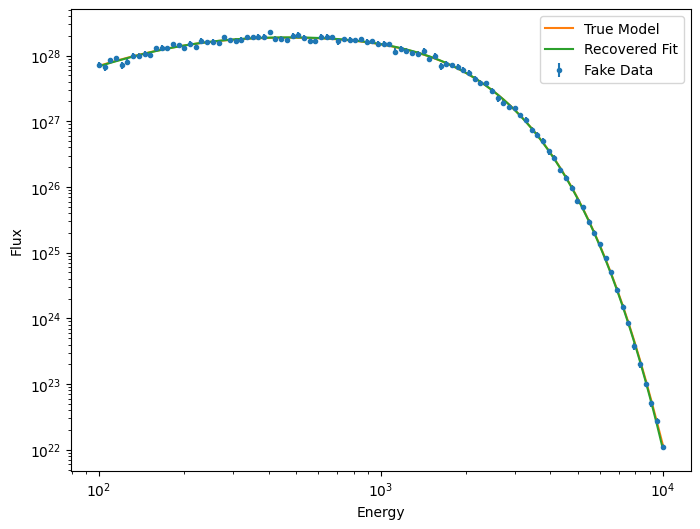

In [81]:
plt.figure(figsize=(8,6))

plt.errorbar(x, y_fake, yerr=yerr, fmt='o', label='Fake Data', markersize=3)

plt.plot(x, y_true, label='True Model')

plt.plot(x, comp(x, A_pow_fit, alpha_fit, A_bb_fit, Tin_fit, Tout_fit), label='Recovered Fit')

plt.xscale("log")
plt.yscale("log")

plt.xlabel("Energy")
plt.ylabel("Flux")

plt.legend()

plt.show()

Perform fits to data.

In [41]:
A_pow_fit, A_pow_err, alpha_fit, alpha_err = pow(x,y,yerr)
A_bb_fit, A_bb_err, T_fit, T_err = bb(x, y, yerr)
A, Aerr, Tin, Tinerr, Tout, Touterr = diskbb(x, y, yerr)
A_pow_fit_comp, A_pow_err_comp, alpha_fit_comp, alpha_err_comp, A_bb_fit_comp, A_bb_err_comp, Tin_fit_comp, Tin_err_comp, Tout_fit_comp, Tout_err_comp = composite(x,y,yerr)
#A_pow_fit_comp, A_pow_err_comp, alpha_fit_comp, alpha_err_comp, A_bb_fit_comp, A_bb_err_comp, T_fit_comp, T_err_comp = composite_bb(x,y,yerr)

/tmp/ipykernel_3767250/3799157389.py:2: RuntimeWarning: overflow encountered in power
  return A * E**(-alpha)
/tmp/ipykernel_3767250/3799157389.py:2: RuntimeWarning: overflow encountered in multiply
  return A * E**(-alpha)
/tmp/ipykernel_3767250/4290172691.py:2: RuntimeWarning: overflow encountered in exp
  return A * (E**3) / (np.exp(E / T) - 1)
/tmp/ipykernel_3767250/1816923606.py:4: RuntimeWarning: invalid value encountered in scalar power
  return (T / Tin)**(-11/3) * blackbody(E, 1, T) / Tin
/tmp/ipykernel_3767250/1816923606.py:10: IntegrationWarning: The occurrence of roundoff error is detected, which prevents 
  the requested tolerance from being achieved.  The error may be 
  underestimated.
  integral, _ = quad(integrand, Tout, Tin, args=(Ei,))
/tmp/ipykernel_3767250/1816923606.py:10: IntegrationWarning: The maximum number of subdivisions (50) has been achieved.
  If increasing the limit yields no improvement it is advised to analyze 
  the integrand in order to determine th

power law fit parameters:
A = 4.828e+24 ± 1.702e+23
alpha = 1.160 ± 0.005

bb fit parameters:
A = 4.898e+12 ± 3.145e+11
T = 667.335 ± 9.649

diskbb fit parameters:
A     = 1.584e+14 ± 9.498e+12
Tin   = 360.188 ± 5.376
Tout  = 3.770 ± 4651616.591

Composite fit parameters:
A_pow  = -1.972e+27 ± inf
alpha  = 156817.887 ± inf
A_bb   = 1.584e+14 ± inf
Tin    = 360.194 ± inf
Tout   = 0.366 ± inf



/tmp/ipykernel_3767250/1271837997.py:6: OptimizeWarning: Covariance of the parameters could not be estimated
  popt, pcov = curve_fit(comp, x, y, sigma=yerr, absolute_sigma=True, p0=[1e22, 2, 1e20, 500, 50], maxfev=20000)


Graph data and calculated fits on a log log scale.

/tmp/ipykernel_3767250/4290172691.py:2: RuntimeWarning: overflow encountered in exp
  return A * (E**3) / (np.exp(E / T) - 1)


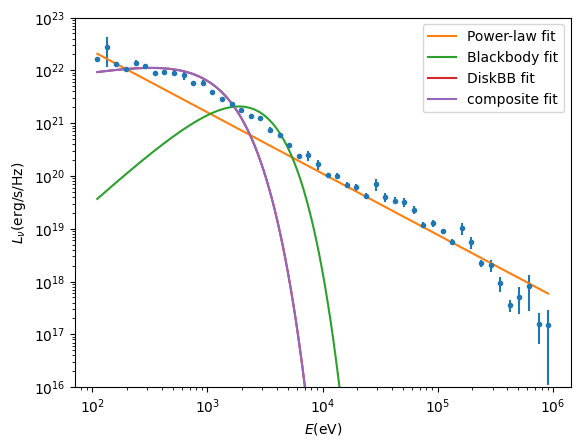

In [42]:
plt.errorbar(x, y, yerr=yerr, fmt='o', markersize=3)

xfit = np.logspace(np.log10(x.min()), np.log10(x.max()), 500)
plt.plot(xfit, power_law(xfit, A_pow_fit, alpha_fit), label='Power-law fit')
plt.plot(xfit, blackbody(xfit, A_bb_fit, T_fit), label='Blackbody fit')
plt.plot(xfit, diskbb_model(xfit, A, Tin, Tout), label='DiskBB fit')
plt.plot(xfit, comp(xfit, A_pow_fit_comp, alpha_fit_comp, A_bb_fit_comp, Tin_fit_comp, Tout_fit_comp), label='composite fit')
#plt.plot(xfit, comp_bb(xfit, A_pow_fit_comp, alpha_fit_comp, A_bb_fit_comp, T_fit_comp), label='composite fit')


plt.xscale("log")
plt.yscale("log")
plt.xlabel(r"$E {\rm (eV)}$")
plt.ylabel(r"$L_\nu {\rm (erg/s/Hz)}$")
plt.ylim(1e16, 1e23)
plt.legend()

plt.show()